In [1]:
#Import packages
#---------------------------------------
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import glob
import admin_functions as adfn
import trace_analyse as tfn
from tqdm import tqdm
import re
import icg_functions as fn

Pass 1: finding trial counts and shared bin bounds...
 density  n_trials  n_extinct  frac_extinct  frac_not_extinct_at_cutoff
0.000100    500000     500000      1.000000                    0.000000
0.000256    500000     500000      1.000000                    0.000000
0.000411    500000     500000      1.000000                    0.000000
0.000567    500000     499989      0.999978                    0.000022
0.000722    500000     422767      0.845534                    0.154466
0.000878    500000     272144      0.544288                    0.455712
0.001033    500000     182492      0.364984                    0.635016
0.001189    500000     128605      0.257210                    0.742790
0.001344    500000      92385      0.184770                    0.815230
0.001500    500000      66488      0.132976                    0.867024

Number of densities: 10
DT: 0.01
Cutoff (s): 10.0

Pass 2: calculating extinct-only histograms...


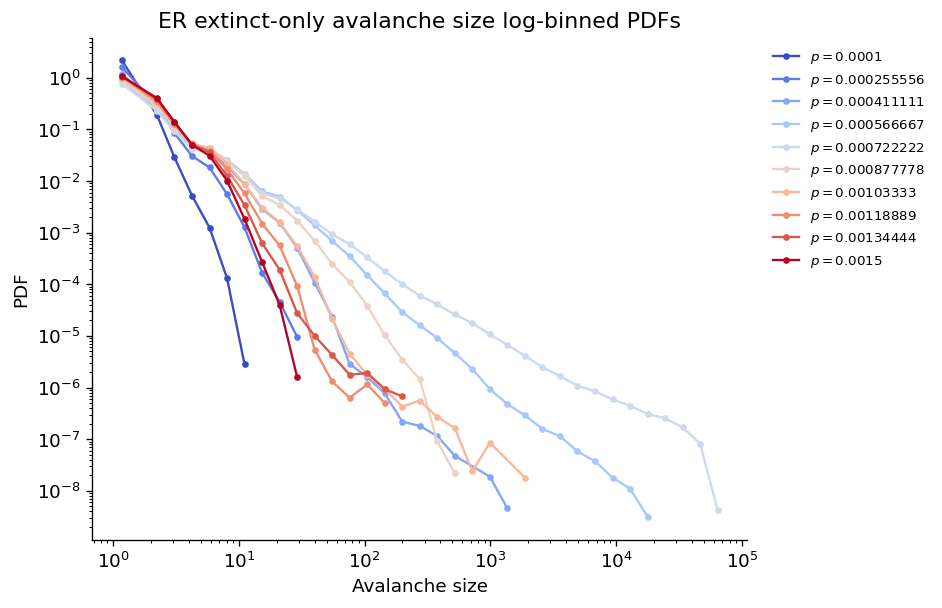

Saved: /home/dburrows/DATA/BLNDEV-WILDTYPE/er_avalanche_ew11p7_iw22p4_N2000_p0p0001_0p001_0p01_3densities_50seeds_10000avals_max1000_2/avalanche_logbinned_pdf_plots_extinct_only/er_avalanche_size_logbinned_pdf_extinct_only.png


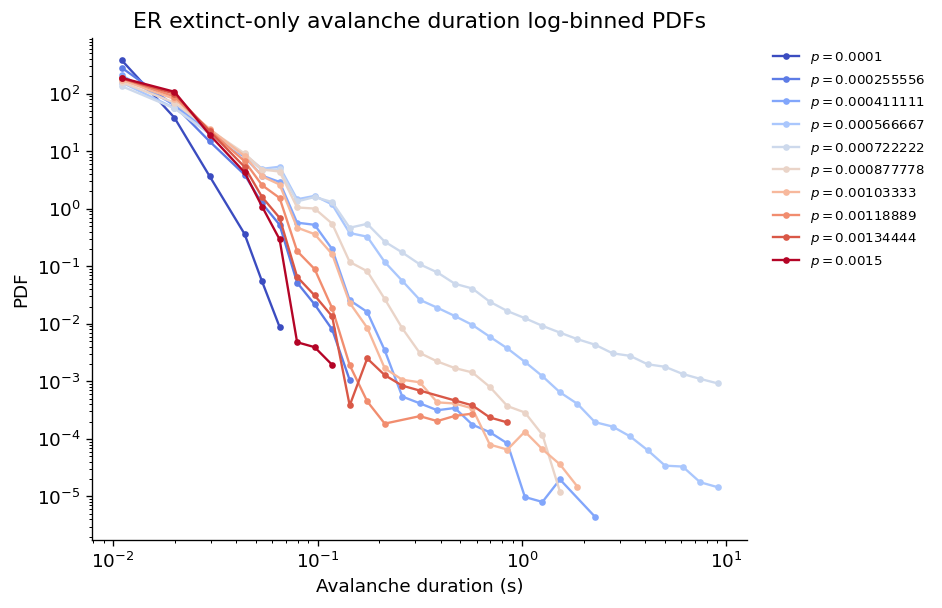

Saved: /home/dburrows/DATA/BLNDEV-WILDTYPE/er_avalanche_ew11p7_iw22p4_N2000_p0p0001_0p001_0p01_3densities_50seeds_10000avals_max1000_2/avalanche_logbinned_pdf_plots_extinct_only/er_avalanche_duration_logbinned_pdf_extinct_only.png

Done. Saved plots to: /home/dburrows/DATA/BLNDEV-WILDTYPE/er_avalanche_ew11p7_iw22p4_N2000_p0p0001_0p001_0p01_3densities_50seeds_10000avals_max1000_2/avalanche_logbinned_pdf_plots_extinct_only


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Settings: completed ER avalanche run
# ============================================================

OUTDIR = Path(
    "/home/dburrows/DATA/BLNDEV-WILDTYPE/"
    "er_avalanche_ew11p7_iw22p4_N2000_p0p0001_0p001_0p01_"
    "3densities_50seeds_10000avals_max1000_2"
)

# Folder name retains "3densities", but your run scanned 10.
TRIALS_PATH = OUTDIR / "avalanche_trials_density_sweep.csv"

FIGDIR = OUTDIR / "avalanche_logbinned_pdf_plots_extinct_only"
FIGDIR.mkdir(parents=True, exist_ok=True)

N_BINS = 35
CHUNKSIZE = 250_000

USECOLS = [
    "density", "size", "lifetime_s",
    "extinct", "dt", "cutoff_s",
]

# ============================================================
# Helpers
# ============================================================

def read_chunks():
    for chunk in pd.read_csv(
        TRIALS_PATH,
        usecols=USECOLS,
        chunksize=CHUNKSIZE,
    ):
        for column in ["density", "size", "lifetime_s", "dt", "cutoff_s"]:
            chunk[column] = pd.to_numeric(chunk[column], errors="coerce")

        if not pd.api.types.is_bool_dtype(chunk["extinct"]):
            parsed = (
                chunk["extinct"]
                .astype(str)
                .str.strip()
                .str.lower()
                .map({
                    "true": True, "false": False,
                    "1": True, "0": False,
                    "1.0": True, "0.0": False,
                })
            )

            if parsed.isna().any():
                raise ValueError("Unrecognised values in extinct column.")

            chunk["extinct"] = parsed.astype(bool)

        if not np.isfinite(chunk["density"]).all():
            raise ValueError("Missing or invalid density values.")

        yield chunk


def make_log_edges(vmin, vmax):
    if not np.isfinite(vmin) or vmin <= 0:
        raise ValueError("Log-bin lower bound must be positive.")

    if not np.isfinite(vmax):
        raise ValueError("Log-bin upper bound must be finite.")

    if vmax <= vmin:
        vmax = 2.0 * vmin

    edges = np.logspace(
        np.log10(vmin), np.log10(vmax), N_BINS + 1
    )
    edges[0], edges[-1] = vmin, vmax
    return edges


def positive_values(series):
    values = series.to_numpy(dtype=float)
    return values[np.isfinite(values) & (values > 0)]


def histogram_pdf(counts, edges):
    total = counts.sum()

    if total == 0:
        return np.array([]), np.array([])

    centres = np.sqrt(edges[:-1] * edges[1:])
    pdf = counts / (total * np.diff(edges))
    keep = counts > 0

    return centres[keep], pdf[keep]


# ============================================================
# Pass 1: counts and shared bin bounds
# ============================================================

counts_by_density = {}
size_max = 1.0
DT = None
MAX_TIME_S = None

print("Pass 1: finding trial counts and shared bin bounds...")

for chunk in read_chunks():
    if chunk.empty:
        continue

    if DT is None:
        DT = float(chunk["dt"].iloc[0])
        MAX_TIME_S = float(chunk["cutoff_s"].iloc[0])

    if (
        not np.isfinite(DT) or DT <= 0
        or not np.isfinite(MAX_TIME_S) or MAX_TIME_S <= 0
    ):
        raise ValueError("Invalid dt or cutoff_s.")

    if not np.allclose(chunk["dt"], DT):
        raise ValueError("Trials have inconsistent dt values.")

    if not np.allclose(chunk["cutoff_s"], MAX_TIME_S):
        raise ValueError("Trials have inconsistent cutoff_s values.")

    for density, group in chunk.groupby("density", sort=False):
        density = float(density)

        record = counts_by_density.setdefault(
            density, {"n_trials": 0, "n_extinct": 0}
        )
        record["n_trials"] += len(group)
        record["n_extinct"] += int(group["extinct"].sum())

    values = positive_values(chunk.loc[chunk["extinct"], "size"])

    if values.size:
        size_max = max(size_max, float(values.max()))

if not counts_by_density:
    raise ValueError("The trial CSV is empty.")

densities = np.array(sorted(counts_by_density))

count_summary = pd.DataFrame([
    {"density": density, **counts_by_density[density]}
    for density in densities
])

count_summary["frac_extinct"] = (
    count_summary["n_extinct"] / count_summary["n_trials"]
)
count_summary["frac_not_extinct_at_cutoff"] = (
    1.0 - count_summary["frac_extinct"]
)

print(count_summary.to_string(index=False))
print("\nNumber of densities:", len(densities))
print("DT:", DT)
print("Cutoff (s):", MAX_TIME_S)

count_summary.to_csv(
    FIGDIR / "er_avalanche_plot_trial_counts.csv",
    index=False,
)

if count_summary["n_extinct"].sum() == 0:
    raise ValueError("No extinct avalanches available to plot.")

# Use identical bin edges across all densities.
size_edges = make_log_edges(1.0, size_max)
duration_edges = make_log_edges(DT, MAX_TIME_S)

size_counts = {
    density: np.zeros(N_BINS, dtype=np.int64)
    for density in densities
}
duration_counts = {
    density: np.zeros(N_BINS, dtype=np.int64)
    for density in densities
}

# ============================================================
# Pass 2: accumulate extinct-only histograms
# ============================================================

print("\nPass 2: calculating extinct-only histograms...")

for chunk in read_chunks():
    extinct_chunk = chunk.loc[chunk["extinct"]]

    for density, group in extinct_chunk.groupby("density", sort=False):
        density = float(density)

        sizes = positive_values(group["size"])
        durations = positive_values(group["lifetime_s"])

        # Avoid silently dropping positive observations outside the bins.
        if sizes.size and (
            sizes.min() < size_edges[0]
            or sizes.max() > size_edges[-1]
        ):
            raise ValueError("Avalanche sizes fall outside shared bin bounds.")

        if durations.size and (
            durations.min() < duration_edges[0]
            or durations.max() > duration_edges[-1]
        ):
            raise ValueError("Avalanche durations fall outside shared bin bounds.")

        size_counts[density] += np.histogram(
            sizes, bins=size_edges
        )[0]

        duration_counts[density] += np.histogram(
            durations, bins=duration_edges
        )[0]

# ============================================================
# Plot size and duration PDFs
# Each density is normalized separately, conditional on extinction.
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

colors = plt.cm.coolwarm(np.linspace(0, 1, len(densities)))
density_to_color = dict(zip(densities, colors))

plot_specs = [
    (
        size_counts,
        size_edges,
        "Avalanche size",
        "ER extinct-only avalanche size log-binned PDFs",
        "er_avalanche_size_logbinned_pdf_extinct_only.png",
    ),
    (
        duration_counts,
        duration_edges,
        "Avalanche duration (s)",
        "ER extinct-only avalanche duration log-binned PDFs",
        "er_avalanche_duration_logbinned_pdf_extinct_only.png",
    ),
]

for histograms, edges, xlabel, title, filename in plot_specs:
    fig, ax = plt.subplots(figsize=(8, 5.2))

    for density in densities:
        x, pdf = histogram_pdf(histograms[density], edges)

        if x.size == 0:
            print(f"No valid extinct trials to plot at p={density:.6g}")
            continue

        ax.plot(
            x,
            pdf,
            marker="o",
            markersize=3,
            linewidth=1.4,
            color=density_to_color[density],
            label=fr"$p={density:.6g}$",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    fig.tight_layout()

    save_path = FIGDIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", save_path)

print("\nDone. Saved plots to:", FIGDIR)